In [36]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [37]:
import time
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import lightgbm as lgb
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [38]:
df = pd.read_csv("../data/processed/processed_data.csv")

In [39]:
# df = pd.read_csv("https://raw.githubusercontent.com/iamnitishsah/FoodOps.AI/refs/heads/main/DemandOps/data/processed/processed_data.csv")

In [40]:
max_week = df['week'].max()
print(f"Max week: {max_week}")

Max week: 145


In [41]:
val_weeks = int(max_week * 0.10)
print(f"Validation weeks: {val_weeks}")

Validation weeks: 14


In [42]:
cutoff_week = max_week - val_weeks
print(f"Cutoff week: {cutoff_week}")

Cutoff week: 131


In [43]:
train_df = df[df['week'] <= cutoff_week].copy()
val_df   = df[df['week'] > cutoff_week].copy()
print(f"Train: weeks 1-{cutoff_week}  -> {len(train_df):,} rows")
print(f"Val:   weeks {cutoff_week+1}-{max_week} -> {len(val_df):,} rows")

Train: weeks 1-131  -> 471,207 rows
Val:   weeks 132-145 -> 50,358 rows


# MAPE(Mean Absolute Percentage Error)

In [44]:
def mape(y_true, y_pred):
    mask = y_true != 0  # avoid div-by-zero; exclude true zeros from MAPE
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / y_true[mask]) * 100

# WAPE(Weighted Absolute Percentage Error)

In [45]:
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100

# Baseline model: naive lag-1 prediction

In [46]:
val_baseline_pred_log = val_df['lag_1']
val_baseline_pred = np.expm1(val_baseline_pred_log)

# clip negative predictions to 0 — orders can't be negative, and expm1 of a small/negative log value could theoretically dip below 0
val_baseline_pred = np.clip(val_baseline_pred, 0, None)

val_actual = np.expm1(val_df['log_num_orders'])  # ground truth, back on orders scale

In [47]:
print(np.allclose(val_actual, val_df['num_orders']))
print((val_actual - val_df['num_orders']).abs().max())

True
2.546585164964199e-11


In [48]:
baseline_mape = mape(val_actual.values, val_baseline_pred.values)
baseline_wape = wape(val_actual.values, val_baseline_pred.values)

print(f"--- Baseline Naive ---")
print(f"WAPE: {baseline_wape:.2f}% | MAPE: {baseline_mape:.2f}%")

--- Baseline Naive ---
WAPE: 41.96% | MAPE: 67.23%


# Regression model: Ridge Regression

In [49]:
# Define feature columns
calendar_features = ['week_of_year']

numeric_features = [
    'checkout_price', 'base_price', 'price_change_pct',
    'lag_1', 'lag_2', 'lag_4',
    'rolling_mean_4', 'rolling_std_4',
    'op_area'
] + calendar_features

binary_features = [
    'emailer_for_promotion',
    'homepage_featured'
]

categorical_features = [
    'category', 'cuisine', 'center_type',
    'center_id', 'meal_id'
]

features = numeric_features + binary_features + categorical_features
target = 'log_num_orders'

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]
val_actual = val_df['num_orders'].values

In [50]:
# Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
    ]
)

In [51]:
# Create and fit Ridge Pipeline
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=10))
])

print("Fitting Ridge model...")
ridge_pipeline.fit(X_train, y_train)

Fitting Ridge model...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['checkout_price','base_price','price_change_pct',...,'center_type', 'center_id','meal_id']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed th

In [52]:
# Predict on Validation set
ridge_pred_log = ridge_pipeline.predict(X_val)

In [53]:
# Transform back to raw orders scale and clip at 0
ridge_pred = np.expm1(ridge_pred_log)
ridge_pred = np.clip(ridge_pred, 0, None)

In [54]:
# Evaluate
ridge_mape = mape(val_actual, ridge_pred)
ridge_wape = wape(val_actual, ridge_pred)

print(f"--- Baseline Naive ---")
print(f"WAPE: {baseline_wape:.2f}% | MAPE: {baseline_mape:.2f}%")
print(f"\n--- Ridge Regression ---")
print(f"WAPE: {ridge_wape:.2f}% | MAPE: {ridge_mape:.2f}%")

--- Baseline Naive ---
WAPE: 41.96% | MAPE: 67.23%

--- Ridge Regression ---
WAPE: 35.72% | MAPE: 46.98%


# Boosting model: LightGBM

In [55]:
# Define feature lists for LightGBM
calendar_features = ['week_of_year']
cat_cols = ['category', 'cuisine', 'center_type', 'center_id', 'meal_id']
num_cols = [
    'checkout_price', 'base_price', 'price_change_pct',
    'emailer_for_promotion', 'homepage_featured',
    'lag_1', 'lag_2', 'lag_4',
    'rolling_mean_4', 'rolling_std_4',
    'op_area'
] + calendar_features

In [56]:
# Prepare X and y, explicitly casting categoricals to 'category' dtype
X_train_lgb = train_df[features].copy()
y_train_lgb = train_df['log_num_orders'].copy()

X_val_lgb   = val_df[features].copy()
y_val_lgb = val_df[target].copy()
val_lgb_actual = val_df['num_orders'].values

for col in cat_cols:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_val_lgb[col]   = X_val_lgb[col].astype('category')

In [57]:
# Instantiate LightGBM Regressor directly
model_lgb = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [58]:
# Fit directly on the DataFrames
model_lgb.fit(
    X_train_lgb,
    y_train_lgb,
    eval_X=X_val_lgb,
    eval_y=y_val_lgb,
    # eval_set=[(X_val_lgb, y_val_lgb)],
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            verbose=50
        )
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022975 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2268
[LightGBM] [Info] Number of data points in the train set: 471207, number of used features: 17
[LightGBM] [Info] Start training from score 4.691348
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l1: 0.539017


,num_leaves,63
,learning_rate,0.05
,n_estimators,1000
,objective,'regression_l1'
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000


In [59]:
# Predict and invert scale
lgb_pred_log = model_lgb.predict(X_val_lgb)
lgb_pred = np.clip(np.expm1(lgb_pred_log), 0, None)

In [60]:
# Compute Metrics
lgb_wape = wape(val_actual, lgb_pred)
lgb_mape = mape(val_actual, lgb_pred)

In [61]:
print(f"\n================ MODEL COMPARISON ================")
print(f"1. Naive Baseline : WAPE = {baseline_wape:.2f}% | MAPE = {baseline_mape:.2f}%")
print(f"2. Ridge Regressor: WAPE = {ridge_wape:.2f}% | MAPE = {ridge_mape:.2f}%")
print(f"3. LightGBM       : WAPE = {lgb_wape:.2f}% | MAPE = {lgb_mape:.2f}%")
print(f"==================================================")


================ MODEL COMPARISON ================
1. Naive Baseline : WAPE = 41.96% | MAPE = 67.23%
2. Ridge Regressor: WAPE = 35.72% | MAPE = 46.98%
3. LightGBM       : WAPE = 28.80% | MAPE = 44.41%


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

Text(0.5, 1.0, 'Feature Importance by Gain (Loss Reduction)')

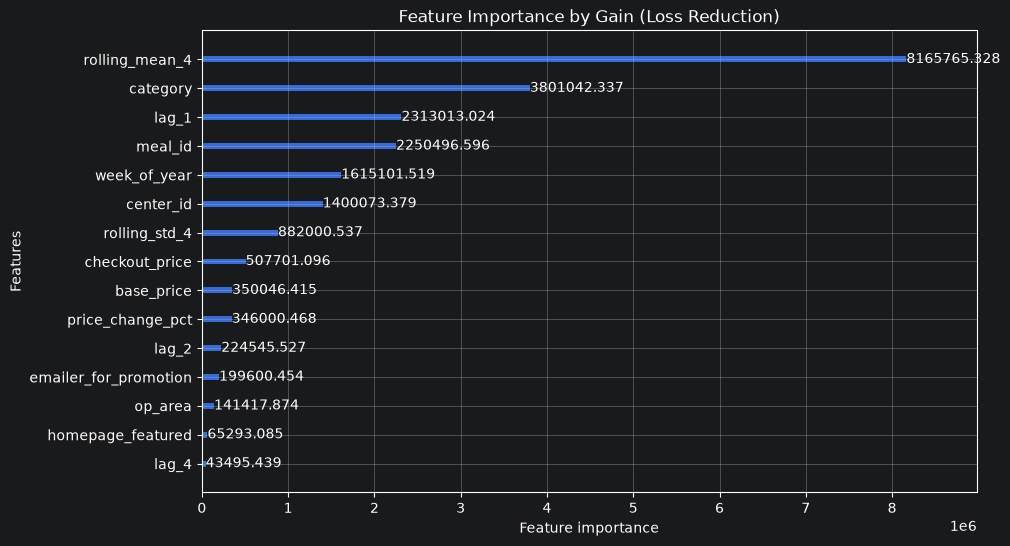

In [62]:
lgb.plot_importance(model_lgb, importance_type='gain', max_num_features=15, figsize=(10, 6))
plt.title("Feature Importance by Gain (Loss Reduction)")
plt.show()

In [63]:
# Ensure output directory exists
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

# Save the standalone scikit-learn compatible LGBMRegressor
joblib.dump(model_lgb, os.path.join(models_dir, "lgb_model.joblib"))

# 2. Recommended: Save an artifact bundle containing feature metadata
lgb_bundle = {
    "model": model_lgb,
    "features": features,
    "cat_cols": cat_cols,
    "target": "num_orders",
    "target_transform": "log1p",  # indicates np.expm1() is needed on predictions
    "metrics": {
        "val_wape": lgb_wape,
        "val_mape": lgb_mape
    }
}
bundle_path = os.path.join(models_dir, "lgb_model_bundle.joblib")
joblib.dump(lgb_bundle, bundle_path)

print(f"Model and bundle successfully exported to: {os.path.abspath(models_dir)}")

['../models/lgb_model.joblib']

['../models/lgb_model_bundle.joblib']

Model and bundle successfully exported to: /Users/iamnitishsah/Documents/Projects/FoodOps.AI/DemandOps/models


# Neural Network Model: LSTM

In [ ]:
# Optimize thread scheduling for M2 P-cores
torch.set_num_threads(4)
device = torch.device('cpu') # CPU is faster than MPS for small LSTMs on Apple Silicon
print(f"Training on device: {device}")

In [64]:
# Trajectory features (what happened over the last 8 weeks)
history_cols = [
    'checkout_price', 'base_price', 'price_change_pct',
    'emailer_for_promotion', 'homepage_featured',
    'week_of_year', 'log_num_orders'
]

# Known future features (what is scheduled for target week t)
target_known_cols = [
    'checkout_price', 'base_price', 'price_change_pct',
    'emailer_for_promotion', 'homepage_featured',
    'week_of_year'
]

# Static continuous entity features
static_num_cols = ['op_area']

Training on device: cpu


In [65]:
# Fit scaler strictly on training weeks (week <= cutoff_week)
train_mask = df['week'] <= cutoff_week
scaler = StandardScaler()
cols_to_scale = list(set(history_cols + target_known_cols + static_num_cols))
scaler.fit(df.loc[train_mask, cols_to_scale])

df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.transform(df[cols_to_scale])

# Target scaler: scale the log target so loss and gradients stay normalized
target_mean = float(df.loc[train_mask, 'log_num_orders'].mean())
target_std  = float(df.loc[train_mask, 'log_num_orders'].std())
df_scaled['target_norm'] = ((df['log_num_orders'] - target_mean) / target_std).astype(np.float32)

print("Feature and target scaling complete.")

StandardScaler()

Feature and target scaling complete.


In [ ]:
print("Vectorizing data into memory (matching DataFrame index order)...")

seq_len = 8
num_weeks = int(df['week'].max())
num_series = len(df) // num_weeks

hist_arr = df_scaled[history_cols].to_numpy(dtype=np.float32).reshape(num_series, num_weeks, len(history_cols))
target_known_arr = df_scaled[target_known_cols].to_numpy(dtype=np.float32).reshape(num_series, num_weeks, len(target_known_cols))
static_num_arr = df_scaled[static_num_cols].to_numpy(dtype=np.float32).reshape(num_series, num_weeks, len(static_num_cols))[:, 0, :]
targets_arr = df_scaled['target_norm'].to_numpy(dtype=np.float32).reshape(num_series, num_weeks)

X_hist_train, X_known_train, X_stat_train, Y_train = [], [], [], []
X_hist_val, X_known_val, X_stat_val, Y_val = [], [], [], []

for s in range(num_series):
    # Train (skip first `seq_len` weeks so we have full history)
    for t in range(seq_len, cutoff_week):
        X_hist_train.append(hist_arr[s, t - seq_len : t, :])
        X_known_train.append(target_known_arr[s, t, :])
        X_stat_train.append(static_num_arr[s, :])
        Y_train.append(targets_arr[s, t])

    # Validation
    for t in range(cutoff_week, num_weeks):
        X_hist_val.append(hist_arr[s, t - seq_len : t, :])
        X_known_val.append(target_known_arr[s, t, :])
        X_stat_val.append(static_num_arr[s, :])
        Y_val.append(targets_arr[s, t])

# Convert to contiguous PyTorch tensors
t_X_hist_train = torch.tensor(np.stack(X_hist_train))
t_X_known_train = torch.tensor(np.stack(X_known_train))
t_X_stat_train = torch.tensor(np.stack(X_stat_train))
t_Y_train = torch.tensor(np.array(Y_train, dtype=np.float32))

t_X_hist_val = torch.tensor(np.stack(X_hist_val))
t_X_known_val = torch.tensor(np.stack(X_known_val))
t_X_stat_val = torch.tensor(np.stack(X_stat_val))
t_Y_val = torch.tensor(np.array(Y_val, dtype=np.float32))

print(f"Train tensor shape: {t_X_hist_train.shape} | Val tensor shape: {t_X_hist_val.shape}")

Vectorizing data into memory (matching DataFrame index order)...


In [ ]:
class SimpleDemandLSTM(nn.Module):
    def __init__(self, history_dim, target_known_dim, num_static_cont, hidden_dim=32, num_layers=1):
        super().__init__()

        # 1. Standard LSTM for the 8-week historical sequence
        self.lstm = nn.LSTM(
            input_size=history_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # 2. Linear layer combining the LSTM summary with current-week features
        combined_dim = hidden_dim + target_known_dim + num_static_cont
        self.fc = nn.Linear(combined_dim, 1)

    def forward(self, x_hist, x_target_known, x_stat_num):
        # Process history through LSTM
        lstm_out, (h_n, c_n) = self.lstm(x_hist)
        last_hidden = h_n[-1]

        # Concatenate outputs and predict
        fusion = torch.cat([last_hidden, x_stat_num, x_target_known], dim=1)
        out = self.fc(fusion)
        return out.squeeze(-1)

In [ ]:
# Initialize the simple model
model = SimpleDemandLSTM(
    history_dim=len(history_cols),
    target_known_dim=len(target_known_cols),
    num_static_cont=len(static_num_cols),
    hidden_dim=32,
    num_layers=1
).to(device)

criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

batch_size = 2048  # Large batch size for CPU vectorization speedup
n_train = t_X_hist_train.shape[0]
n_val = t_X_hist_val.shape[0]
epochs = 10

best_wape = float("inf")
best_mape = float("inf")

# Ensure val_actual exactly matches original dataframe
val_actual = val_df['num_orders'].values

print("Starting Fast M2 Training Loop...\n")

for epoch in range(1, epochs + 1):
    epoch_start = time.time()
    model.train()

    # Shuffle indices per epoch
    perm = torch.randperm(n_train)
    total_train_loss = 0.0

    # --- TRAINING PHASE ---
    for i in range(0, n_train, batch_size):
        idx = perm[i : i + batch_size]

        # Direct tensor slicing (fast)
        b_hist = t_X_hist_train[idx].to(device)
        b_known = t_X_known_train[idx].to(device)
        b_stat = t_X_stat_train[idx].to(device)
        b_y = t_Y_train[idx].to(device)

        optimizer.zero_grad(set_to_none=True)
        preds = model(b_hist, b_known, b_stat)
        loss = criterion(preds, b_y)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * len(b_y)

    avg_train_loss = total_train_loss / n_train

    # --- VALIDATION PHASE ---
    model.eval()
    val_preds = []
    total_val_loss = 0.0

    with torch.no_grad():
        for i in range(0, n_val, batch_size * 2):
            b_hist = t_X_hist_val[i : i + batch_size * 2].to(device)
            b_known = t_X_known_val[i : i + batch_size * 2].to(device)
            b_stat = t_X_stat_val[i : i + batch_size * 2].to(device)
            b_y = t_Y_val[i : i + batch_size * 2].to(device)

            p = model(b_hist, b_known, b_stat)
            loss = criterion(p, b_y)
            total_val_loss += loss.item() * len(b_y)
            val_preds.append(p.cpu().numpy())

    avg_val_loss = total_val_loss / n_val
    val_preds_norm = np.concatenate(val_preds, axis=0)

    # Un-scale predictions
    preds_log = val_preds_norm * target_std + target_mean
    raw_preds = np.clip(np.expm1(preds_log), 0, None)

    # Compute business metrics
    current_wape = wape(val_actual, raw_preds)
    current_mape = mape(val_actual, raw_preds)

    is_best = current_wape < best_wape
    if is_best:
        best_wape = current_wape
        best_mape = current_mape

    elapsed = time.time() - epoch_start
    print(
        f"Epoch {epoch:02d}/{epochs:02d} ({elapsed:.1f}s) | "
        f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
        f"Val WAPE: {current_wape:.2f}% | Val MAPE: {current_mape:.2f}%"
        + (" [★ Best]" if is_best else "")
    )

print(f"\nFinal Best Simple LSTM Validation WAPE: {best_wape:.2f}%")

In [ ]:
print(f"\n================ MODEL COMPARISON ================")
print(f"1. Naive Baseline : WAPE = {baseline_wape:.2f}% | MAPE = {baseline_mape:.2f}%")
print(f"2. Ridge Regressor: WAPE = {ridge_wape:.2f}% | MAPE = {ridge_mape:.2f}%")
print(f"3. LightGBM       : WAPE = {lgb_wape:.2f}% | MAPE = {lgb_mape:.2f}%")
print(f"4. Simple LSTM    : WAPE = {best_wape:.2f}% | MAPE = {best_mape:.2f}%")
print(f"==================================================")